## Aphasia vs Controls Mainconcept Analysis


### Load Data for patients data and mainconcept data

In [5]:
import pandas as pd
import numpy as np

controls_features_df = pd.read_csv('../../data/classification/aphasia_controls_mainconcept_features_update_qsub.csv')   # Replace with the actual filename
print(controls_features_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   participant                             113 non-null    object 
 1   total_utterances                        113 non-null    int64  
 2   distance_to_centroid                    113 non-null    float64
 3   num_unique_main_concepts                113 non-null    int64  
 4   num_total_main_concepts                 113 non-null    int64  
 5   unique_main_concept_match_ratio         113 non-null    float64
 6   total_main_concept_match_ratio          113 non-null    float64
 7   sequence_score_mainconcept              113 non-null    float64
 8   local_coherence_mainconcept             113 non-null    float64
 9   global_coherence_mainconcept            113 non-null    float64
 10  num_topic_switching                     113 non-null    int64 

In [6]:
participants_df = pd.read_csv('../../data/classification/combined_patient_data_111725.csv')  
print(participants_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Corpus             309 non-null    object 
 1   participant        309 non-null    object 
 2   age                302 non-null    object 
 3   sex                309 non-null    object 
 4   diagnosis          309 non-null    object 
 5   WAB score          102 non-null    float64
 6   standardized MOCA  132 non-null    float64
 7   gen_diagnosis      309 non-null    object 
dtypes: float64(2), object(6)
memory usage: 19.4+ KB
None


In [7]:
# Conditionally create combined ID only if Participant_Code starts with a numerical value (digit)
participants_df['combined_id'] = np.where(
    participants_df['participant'].str[0].str.isdigit(),
    participants_df['Corpus'].str.lower().str.strip() + participants_df['participant'].str.strip(),
    participants_df['participant'].str.strip()  # Fallback to just participant code if condition not met
)

participants_df['combined_id'] = participants_df['combined_id'].str.lower()

# Output the combined IDs
print(participants_df['combined_id'].tolist())

['delaware02-1', 'delaware03-1', 'delaware04-1', 'delaware05-1', 'delaware07-1', 'delaware08-1', 'delaware101-1', 'delaware12-1', 'delaware13-1', 'delaware200-1', 'delaware201-1', 'delaware203-1', 'delaware204-1', 'delaware208-1', 'delaware209-1', 'delaware214-1', 'delaware218-1', 'delaware220-1', 'delaware221-1', 'delaware224-1', 'delaware225-1', 'delaware226-1', 'delaware227-1', 'delaware228-1', 'delaware229-1', 'delaware233-1', 'delaware234-1', 'delaware235-1', 'delaware24-1', 'delaware244-1', 'delaware25-1', 'delaware270-1', 'delaware271-1', 'delaware276-1', 'delaware278-1', 'delaware279-1', 'delaware29-1', 'delaware30-1', 'delaware35-1', 'delaware36-1', 'delaware37-1', 'delaware38-1', 'delaware39-1', 'delaware42-1', 'delaware44-1', 'delaware45-1', 'delaware46-1', 'delaware48-1', 'delaware60-1', 'delaware62-1', 'delaware65-1', 'delaware67-1', 'delaware70-1', 'delaware77-1', 'delaware81-1', 'delaware84-1', 'delaware86-1', 'delaware87-1', 'delaware90-1', 'delaware92-1', 'delaware93-1

In [8]:
controls_df = participants_df[participants_df['gen_diagnosis'] == 'Control']
aphasia_df = participants_df[participants_df['gen_diagnosis'] == 'Aphasia']
print(aphasia_df['combined_id'].tolist())
# print(len(controls_df))
# print(controls_df.info())

['acwt02a', 'acwt04a', 'acwt08a', 'acwt09a', 'acwt10a', 'acwt12a', 'adler02a', 'adler03a', 'adler04a', 'adler05a', 'adler06a', 'adler15a', 'baycrest12288a', 'baycrest12308a', 'baycrest12331a', 'baycrest9336a', 'baycrest9772a', 'baycrest10634a', 'baycrest10827a', 'baycrest11154a', 'baycrest12072a', 'elman01a', 'elman05a', 'elman07a', 'elman10a', 'elman14a', 'elman15a', 'fridriksson01a', 'fridriksson02a', 'fridriksson04a', 'fridriksson05a', 'fridriksson07a', 'fridriksson09a', 'fridriksson10a', 'fridriksson11a', 'fridriksson12a', 'fridriksson13a', 'mma08a', 'mma11a', 'mma12a', 'mma13a', 'mma14a', 'mma19a', 'richardson08a', 'richardson09a', 'richardson11a', 'richardson14a', 'richardson15a', 'richardson16a', 'richardson17a', 'richardson20a', 'richardson21a', 'richardson26a', 'richardson27a', 'richardson28a', 'richardson30a', 'richardson31a', 'scale22a', 'scale32a', 'tap04a', 'tap05a', 'tap11a', 'tap13a', 'unh01a', 'unh03b', 'unh05c', 'unh08a', 'unh10c', 'unh11b', 'unh14a', 'whiteside01a', '

### Check if any participants is missing in Controls and aphasia from features and participants data

In [9]:
# unique IDs from each side
p_ids = set(controls_df['combined_id'])
f_ids = set(controls_features_df['participant'])
print(len(p_ids)), 
print(len(f_ids))

# who is in participants_df but NOT in controls_features_df
missing_in_features = p_ids - f_ids

# who is in controls_features_df but NOT in participants_df
missing_in_participants = f_ids - p_ids

print("Missing in controls_features_df:", missing_in_features)
print("Missing in participants_df:", missing_in_participants)

113
113
Missing in controls_features_df: set()
Missing in participants_df: set()


In [10]:
aphasia_features_df = pd.read_csv('../../data/classification/aphasia_mainconcept_features_update_qsub.csv')  
(aphasia_features_df['participant']) = aphasia_features_df['participant'].str.lower()
# print(aphasia_features_df.info())

print(aphasia_features_df['participant'].tolist())

['elman07a', 'richardson17a', 'tap04a', 'unh11b', 'whiteside04a', 'williamson13a', 'whiteside05a', 'adler03a', 'unh05c', 'whiteside12a', 'adler15a', 'adler05a', 'mma08a', 'whiteside09a', 'fridriksson10a', 'baycrest9772a', 'tap13a', 'scale22a', 'mma19a', 'fridriksson01a', 'whiteside15a', 'wozniak04a', 'elman10a', 'wright201a', 'acwt12a', 'mma11a', 'adler02a', 'baycrest10634a', 'baycrest9336a', 'mma13a', 'unh10c', 'whiteside18a', 'fridriksson13a', 'richardson31a', 'adler04a', 'fridriksson05a', 'unh01a', 'whiteside17a', 'fridriksson07a', 'wozniak06a', 'richardson08a', 'williamson06a', 'baycrest11154a', 'unh14a', 'elman15a', 'fridriksson02a', 'fridriksson09a', 'elman01a', 'acwt04a', 'wright202a', 'unh03b', 'whiteside01a', 'mma12a', 'wright203a', 'mma14a', 'whiteside14a', 'richardson30a', 'acwt09a', 'whiteside10a', 'elman05a', 'richardson16a', 'richardson27a', 'richardson20a', 'baycrest12072a', 'adler06a', 'whiteside06a', 'scale32a', 'wozniak02a', 'williamson07a', 'whiteside07a', 'richardso

In [11]:
# unique IDs from each side
p_ids = set(aphasia_df['combined_id'])
f_ids = set(aphasia_features_df['participant'])

# who is in participants_df but NOT in controls_features_df
missing_in_features = p_ids - f_ids

# who is in controls_features_df but NOT in participants_df
missing_in_participants = f_ids - p_ids

print("Missing in aphasia_features_df:", missing_in_features)
print("Missing in participants_df:", missing_in_participants)

Missing in aphasia_features_df: set()
Missing in participants_df: set()


### Merge and concatenate Dataframe Controls and Aphasia


In [12]:
controls_df['participant'] = controls_df['combined_id']
controls_df = controls_df.drop(columns=['combined_id'])

controls_combined_df = pd.merge(controls_df, controls_features_df, on='participant', how='inner')
controls_combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 31 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Corpus                                  113 non-null    object 
 1   participant                             113 non-null    object 
 2   age                                     113 non-null    object 
 3   sex                                     113 non-null    object 
 4   diagnosis                               113 non-null    object 
 5   WAB score                               0 non-null      float64
 6   standardized MOCA                       66 non-null     float64
 7   gen_diagnosis                           113 non-null    object 
 8   total_utterances                        113 non-null    int64  
 9   distance_to_centroid                    113 non-null    float64
 10  num_unique_main_concepts                113 non-null    int64 

/scratch/ipykernel_1642568/245591086.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  controls_df['participant'] = controls_df['combined_id']


In [13]:
aphasia_df['participant'] = aphasia_df['combined_id']
aphasia_df = aphasia_df.drop(columns=['combined_id'])

aphasia_combined_df = pd.merge(aphasia_df, aphasia_features_df, on='participant', how='inner')
print(len(aphasia_df))
print(len(aphasia_features_df))
aphasia_combined_df.info()

102
102
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 31 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Corpus                                  102 non-null    object 
 1   participant                             102 non-null    object 
 2   age                                     102 non-null    object 
 3   sex                                     102 non-null    object 
 4   diagnosis                               102 non-null    object 
 5   WAB score                               102 non-null    float64
 6   standardized MOCA                       0 non-null      float64
 7   gen_diagnosis                           102 non-null    object 
 8   total_utterances                        102 non-null    int64  
 9   distance_to_centroid                    102 non-null    float64
 10  num_unique_main_concepts                102 non-null  

/scratch/ipykernel_1642568/3901510765.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aphasia_df['participant'] = aphasia_df['combined_id']


## Concetenate the patients and controls data


In [14]:
all_df = pd.concat([aphasia_combined_df, controls_combined_df], ignore_index=True)
all_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 31 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Corpus                                  215 non-null    object 
 1   participant                             215 non-null    object 
 2   age                                     215 non-null    object 
 3   sex                                     215 non-null    object 
 4   diagnosis                               215 non-null    object 
 5   WAB score                               102 non-null    float64
 6   standardized MOCA                       66 non-null     float64
 7   gen_diagnosis                           215 non-null    object 
 8   total_utterances                        215 non-null    int64  
 9   distance_to_centroid                    215 non-null    float64
 10  num_unique_main_concepts                215 non-null    int64 

## Drop the unnecessary columns

In [15]:
columns_to_drop = ['sex','Corpus','WAB score', 'diagnosis', 'age', 'standardized MOCA', ]
num_df = all_df.drop(columns=columns_to_drop)
num_cols = num_df.columns
print(num_cols)


Index(['participant', 'gen_diagnosis', 'total_utterances',
       'distance_to_centroid', 'num_unique_main_concepts',
       'num_total_main_concepts', 'unique_main_concept_match_ratio',
       'total_main_concept_match_ratio', 'sequence_score_mainconcept',
       'local_coherence_mainconcept', 'global_coherence_mainconcept',
       'num_topic_switching', 'ratio_topic_switching_percent',
       'num_missing_referent', 'ratio_missing_referent_percent',
       'num_tangential_utterance', 'ratio_tangential_utterance_percent',
       'num_propositional_repetition',
       'ratio_propositional_repetition_percent', 'num_filler',
       'ratio_filler_percent', 'num_conceptual_incongruence',
       'ratio_conceptual_incongruence_percent', 'num_coherent',
       'ratio_coherent_percent'],
      dtype='object')


In [16]:
patients_df = num_df[num_df['gen_diagnosis'] == 'Aphasia']
controls_df = num_df[num_df['gen_diagnosis'] == 'Control']

print(f"Number of patients: {len(patients_df)}")
print(f"Number of controls: {len(controls_df)}")

Number of patients: 102
Number of controls: 113


### Density Plot after z-score normalization

In [17]:
import numpy as np
import pandas as pd

# columns to scale: all numeric except the label column(s)
num_cols = num_df.select_dtypes(include='number').columns.tolist()
for c in ['group']:
    if c in num_cols:
        num_cols.remove(c)

# fit params on the whole df
means = num_df[num_cols].mean()
stds  = num_df[num_cols].std(ddof=0).replace(0, np.nan)  # avoid div-by-zero

# normalized copy
df_z = all_df.copy()
df_z[num_cols] = (num_df[num_cols] - means) / stds

# if you prefer to keep zero-variance columns as 0 instead of NaN:
df_z[num_cols] = df_z[num_cols].fillna(0)

# split back to groups (normalized)
patients_df_z = df_z[df_z['gen_diagnosis'] == 'Aphasia'].copy()
controls_df_z = df_z[df_z['gen_diagnosis'] == 'Control'].copy()


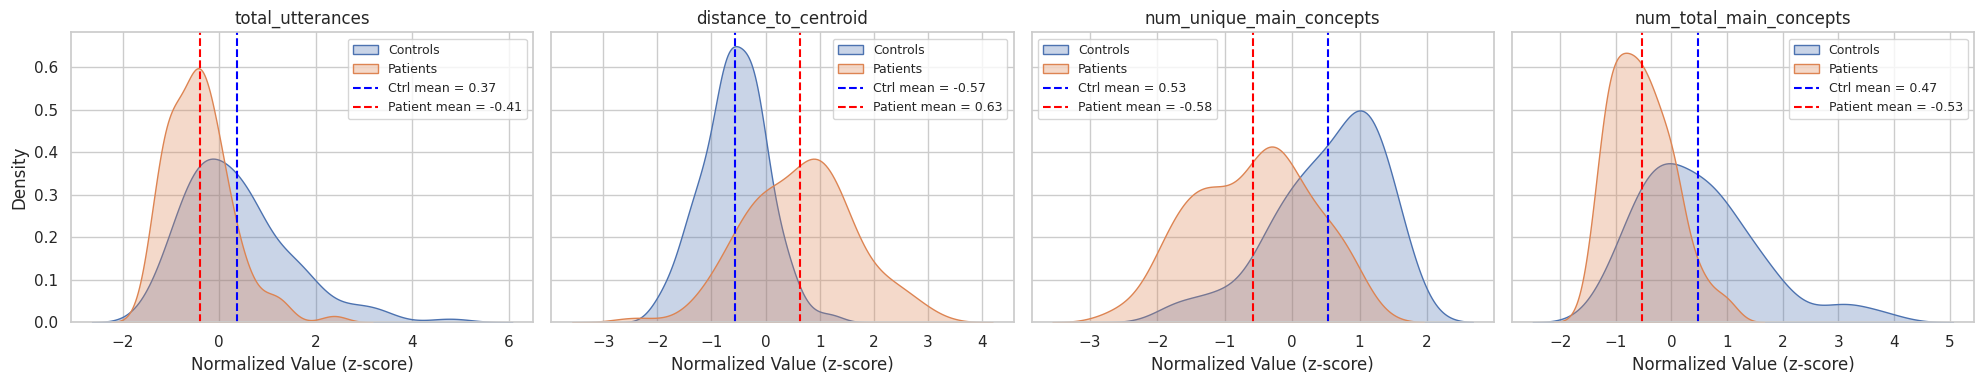

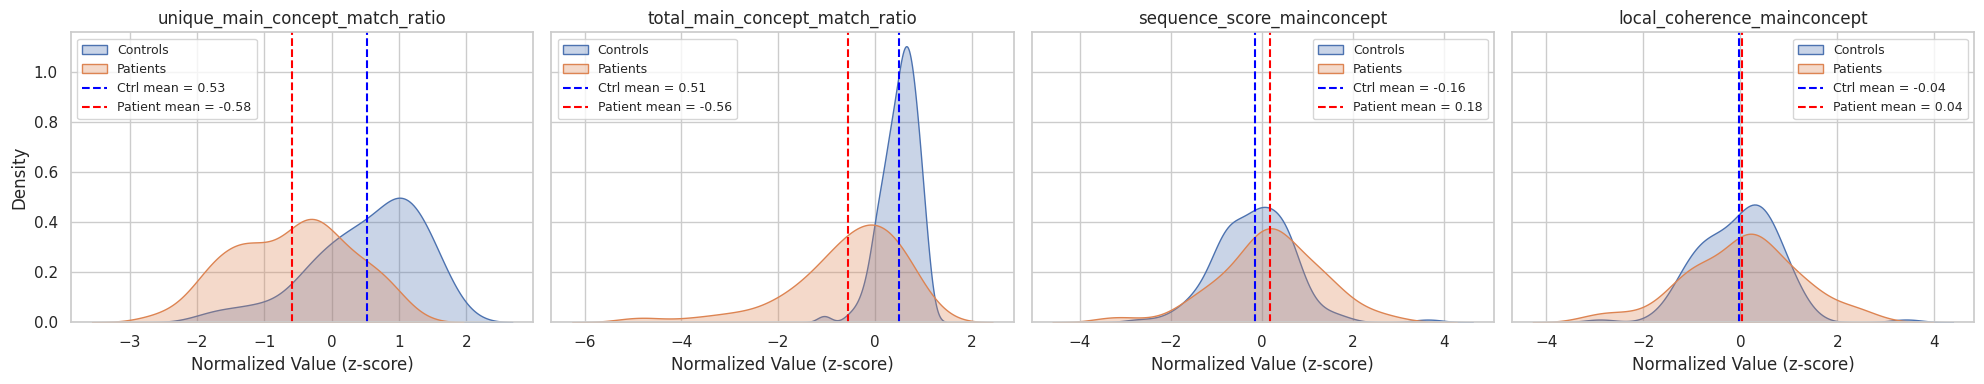

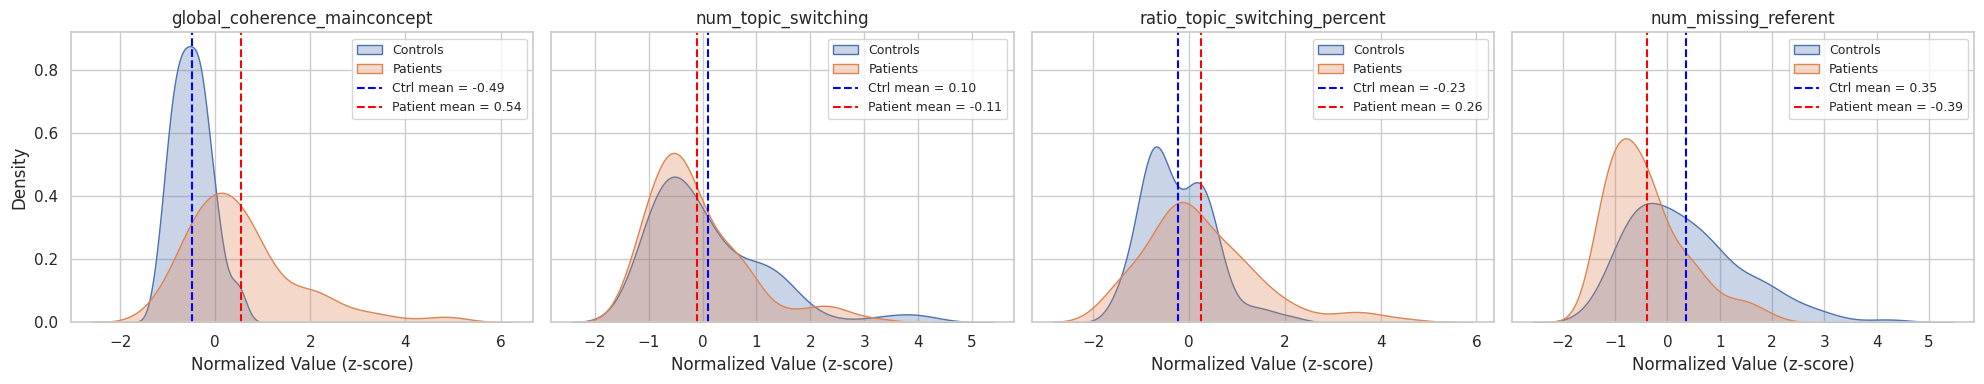

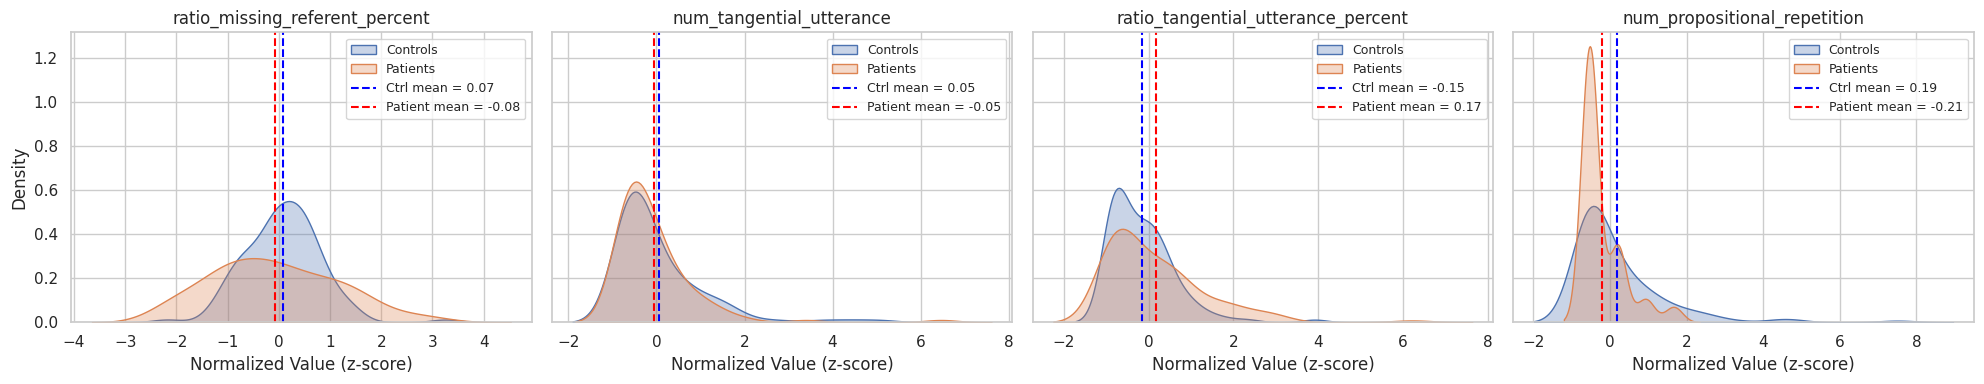

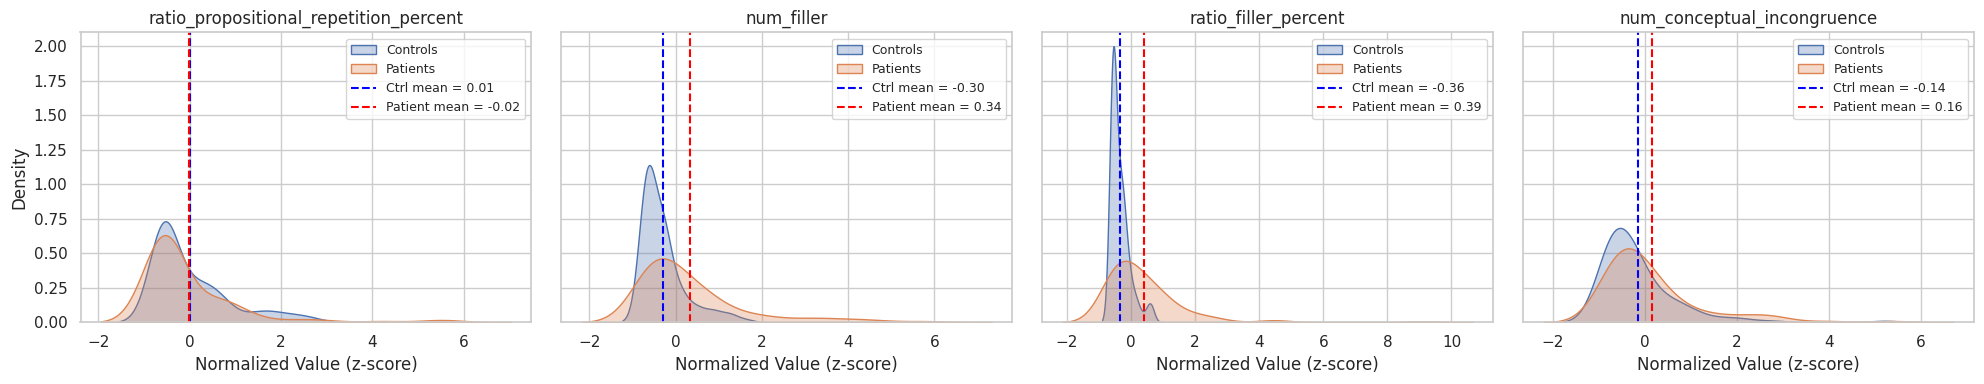

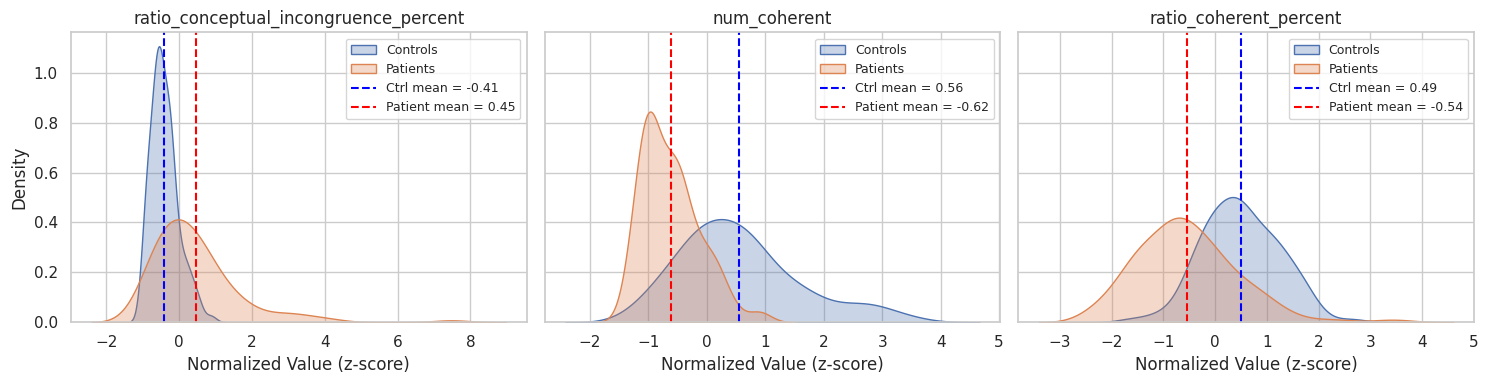

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plots_per_row = 4

for i in range(0, len(num_cols), plots_per_row):
    cols_batch = num_cols[i:i + plots_per_row]

    fig, axes = plt.subplots(
        1, len(cols_batch),
        figsize=(5 * len(cols_batch), 4),
        sharey=True
    )

    # Handle case where there's only one subplot
    if len(cols_batch) == 1:
        axes = [axes]

    for ax, col in zip(axes, cols_batch):
        # KDE plots
        sns.kdeplot(
            data=controls_df_z,
            x=col,
            fill=True,
            alpha=0.3,
            label='Controls',
            ax=ax
        )
        sns.kdeplot(
            data=patients_df_z,
            x=col,
            fill=True,
            alpha=0.3,
            label='Patients',
            ax=ax
        )

        # Medians
        median_ctrl = controls_df_z[col].mean()
        median_pat  = patients_df_z[col].mean()

        ax.axvline(
            median_ctrl,
            color='blue',
            linestyle='--',
            linewidth=1.5,
            label=f'Ctrl mean = {median_ctrl:.2f}'
        )
        ax.axvline(
            median_pat,
            color='red',
            linestyle='--',
            linewidth=1.5,
            label=f'Patient mean = {median_pat:.2f}'
        )

        ax.set_title(col)
        ax.set_xlabel('Normalized Value (z-score)')
        ax.set_ylabel('Density')

        # ✅ Individual legend per subplot
        ax.legend(fontsize=9)

    fig.tight_layout()
    plt.show()


In [19]:
print(num_df.columns)

Index(['participant', 'gen_diagnosis', 'total_utterances',
       'distance_to_centroid', 'num_unique_main_concepts',
       'num_total_main_concepts', 'unique_main_concept_match_ratio',
       'total_main_concept_match_ratio', 'sequence_score_mainconcept',
       'local_coherence_mainconcept', 'global_coherence_mainconcept',
       'num_topic_switching', 'ratio_topic_switching_percent',
       'num_missing_referent', 'ratio_missing_referent_percent',
       'num_tangential_utterance', 'ratio_tangential_utterance_percent',
       'num_propositional_repetition',
       'ratio_propositional_repetition_percent', 'num_filler',
       'ratio_filler_percent', 'num_conceptual_incongruence',
       'ratio_conceptual_incongruence_percent', 'num_coherent',
       'ratio_coherent_percent'],
      dtype='object')


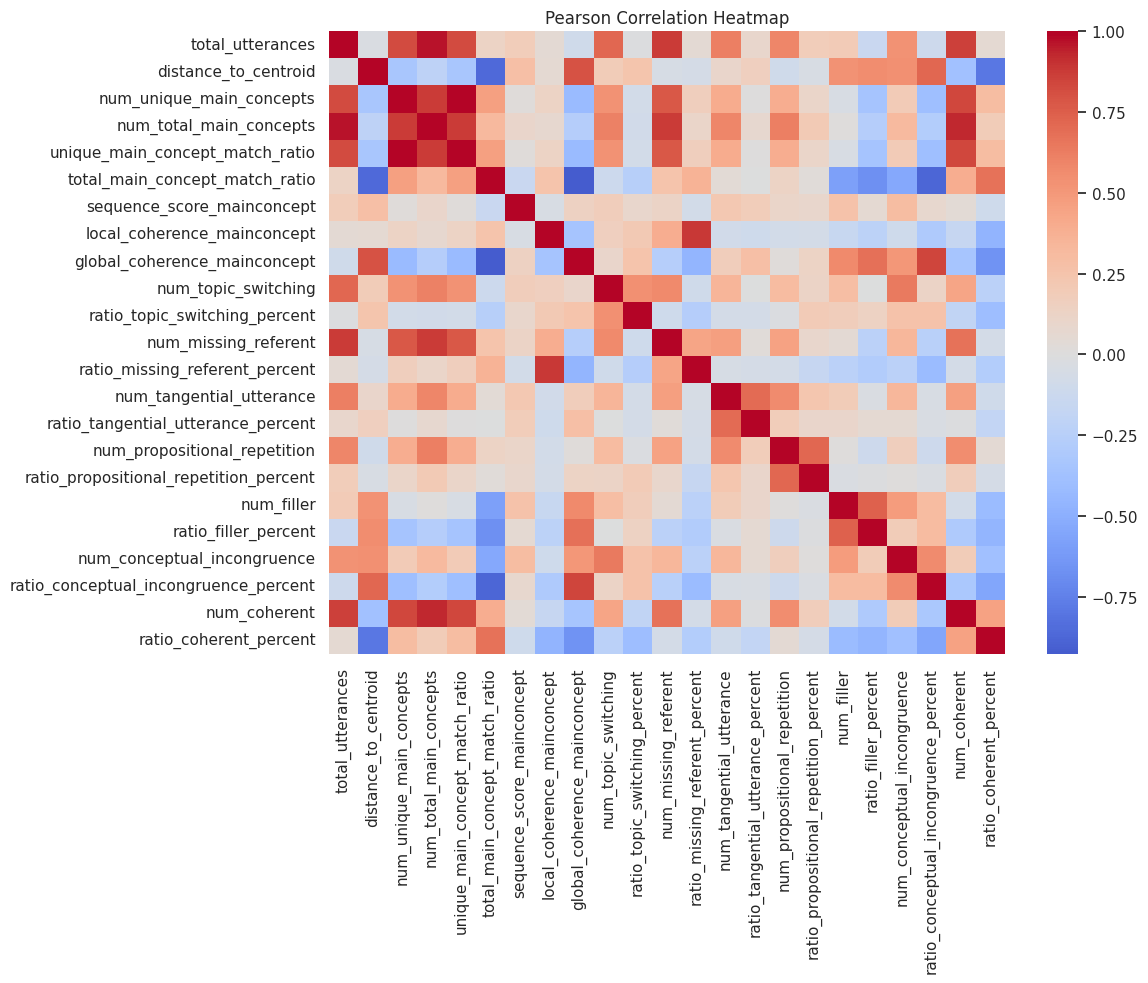

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute Pearson correlation
corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()

In [21]:
import numpy as np

# Take absolute values
corr_abs = corr.abs()

# Mask the diagonal (self correlations)
np.fill_diagonal(corr_abs.values, 0)

# Find pairs above threshold
high_corr_pairs = np.where(corr_abs > 0.8)

pairs = []
for i, j in zip(*high_corr_pairs):
    if i < j:  # avoid duplicates
        pairs.append((
            corr.index[i],
            corr.columns[j],
            corr.iloc[i, j]   # original (signed) correlation value
        ))

In [22]:
for a, b, r in pairs:
    print(f"{a}  <-->  {b}   r = {r:.3f}")

total_utterances  <-->  num_unique_main_concepts   r = 0.824
total_utterances  <-->  num_total_main_concepts   r = 0.966
total_utterances  <-->  unique_main_concept_match_ratio   r = 0.824
total_utterances  <-->  num_missing_referent   r = 0.875
total_utterances  <-->  num_coherent   r = 0.862
distance_to_centroid  <-->  total_main_concept_match_ratio   r = -0.860
distance_to_centroid  <-->  global_coherence_mainconcept   r = 0.802
num_unique_main_concepts  <-->  num_total_main_concepts   r = 0.874
num_unique_main_concepts  <-->  unique_main_concept_match_ratio   r = 1.000
num_unique_main_concepts  <-->  num_coherent   r = 0.835
num_total_main_concepts  <-->  unique_main_concept_match_ratio   r = 0.874
num_total_main_concepts  <-->  num_missing_referent   r = 0.879
num_total_main_concepts  <-->  num_coherent   r = 0.927
unique_main_concept_match_ratio  <-->  num_coherent   r = 0.835
total_main_concept_match_ratio  <-->  global_coherence_mainconcept   r = -0.927
total_main_concept_match

In [23]:
cols_to_remove = []
cols_to_remove.extend([
    "total_utterances",
    "num_unique_main_concepts",
    "num_total_main_concepts",
    "local_coherence_mainconcept",
    "global_coherence_mainconcept",
    # "ratio_coherent_percent",
    "num_coherent",
    # "ratio_conceptual_incongruence_percent",
    "total_main_concept_match_ratio",
])

df_clean = num_df.drop(columns=cols_to_remove, errors="ignore")
feature_cols = df_clean.columns

corr = df_clean.corr(numeric_only=True)


In [24]:
corr = df_clean.corr(numeric_only=True)


In [25]:
import numpy as np

# Take absolute values
corr_abs = corr.abs()

# Mask the diagonal (self correlations)
np.fill_diagonal(corr_abs.values, 0)

# Find pairs above threshold
high_corr_pairs = np.where(corr_abs > 0.8)

pairs = []
for i, j in zip(*high_corr_pairs):
    if i < j:  # avoid duplicates
        pairs.append((
            corr.index[i],
            corr.columns[j],
            corr.iloc[i, j]   # original (signed) correlation value
        ))

for a, b, r in pairs:
    print(f"{a}  <-->  {b}   r = {r:.3f}")

### Logistic Regression Classification

In [26]:
df_ml = df_z.drop(columns=cols_to_remove + columns_to_drop, errors='ignore').copy()
df_ml = df_ml[df_ml['gen_diagnosis'].isin(['Aphasia', 'Control'])].copy()
df_ml['label'] = (df_ml['gen_diagnosis'] == 'Aphasia').astype(int)
df_ml = df_ml.drop(columns=['gen_diagnosis'], errors='ignore')
participants = df_ml['participant']
print(df_ml.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 18 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   participant                             215 non-null    object 
 1   distance_to_centroid                    215 non-null    float64
 2   unique_main_concept_match_ratio         215 non-null    float64
 3   sequence_score_mainconcept              215 non-null    float64
 4   num_topic_switching                     215 non-null    float64
 5   ratio_topic_switching_percent           215 non-null    float64
 6   num_missing_referent                    215 non-null    float64
 7   ratio_missing_referent_percent          215 non-null    float64
 8   num_tangential_utterance                215 non-null    float64
 9   ratio_tangential_utterance_percent      215 non-null    float64
 10  num_propositional_repetition            215 non-null    float6

In [27]:
y = df_ml['label']

X = df_ml.drop(
    columns=[
        'label',
        'participant',      # or 'combined_id' depending on what you kept
    ],
    errors='ignore'
)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    solver='liblinear',
    max_iter=500,
    class_weight='balanced'  # good for class imbalance
)

logreg.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,500
,multi_class,'deprecated'


In [29]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = logreg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8837209302325582

Classification report:
               precision    recall  f1-score   support

           0       0.85      0.96      0.90        23
           1       0.94      0.80      0.86        20

    accuracy                           0.88        43
   macro avg       0.89      0.88      0.88        43
weighted avg       0.89      0.88      0.88        43



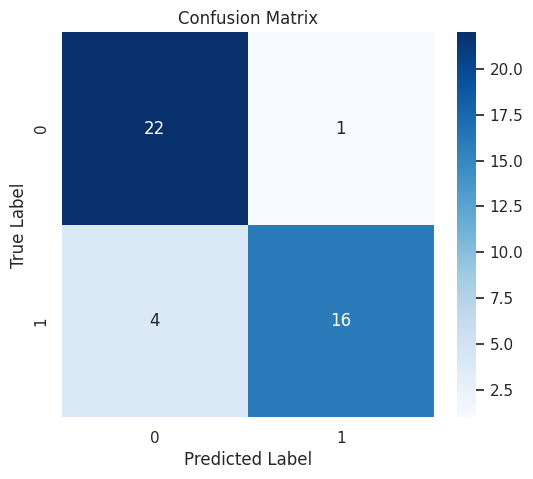

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [31]:
# Boolean masks for errors
false_neg_mask = (y_test == 1) & (y_pred == 0)
false_pos_mask = (y_test == 0) & (y_pred == 1)

# Get participant codes by aligning indices to the original df
false_negative_participants = df_ml.loc[X_test.index[false_neg_mask], 'participant'].tolist()
false_positive_participants = df_ml.loc[X_test.index[false_pos_mask], 'participant'].tolist()

print("False Negatives:", false_negative_participants)
print("False Positives:", false_positive_participants)



False Negatives: ['fridriksson11a', 'fridriksson13a', 'wright203a', 'richardson08a']
False Positives: ['delaware03-1']


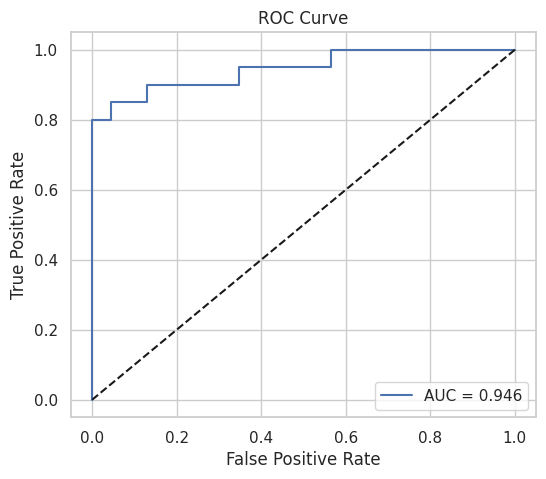

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_proba = logreg.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_value = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_value:.3f}")
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [33]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": logreg.coef_[0]
}).sort_values("coefficient", ascending=False)

print(coef_df)

                                   feature  coefficient
0                     distance_to_centroid     1.651056
11                              num_filler     0.717768
7                 num_tangential_utterance     0.529186
10  ratio_propositional_repetition_percent     0.503058
2               sequence_score_mainconcept     0.381645
12                    ratio_filler_percent     0.291915
14   ratio_conceptual_incongruence_percent     0.261192
4            ratio_topic_switching_percent     0.140826
6           ratio_missing_referent_percent     0.117477
3                      num_topic_switching    -0.121882
13             num_conceptual_incongruence    -0.350057
9             num_propositional_repetition    -0.401302
15                  ratio_coherent_percent    -0.403644
8       ratio_tangential_utterance_percent    -0.405145
5                     num_missing_referent    -0.757384
1          unique_main_concept_match_ratio    -1.111367


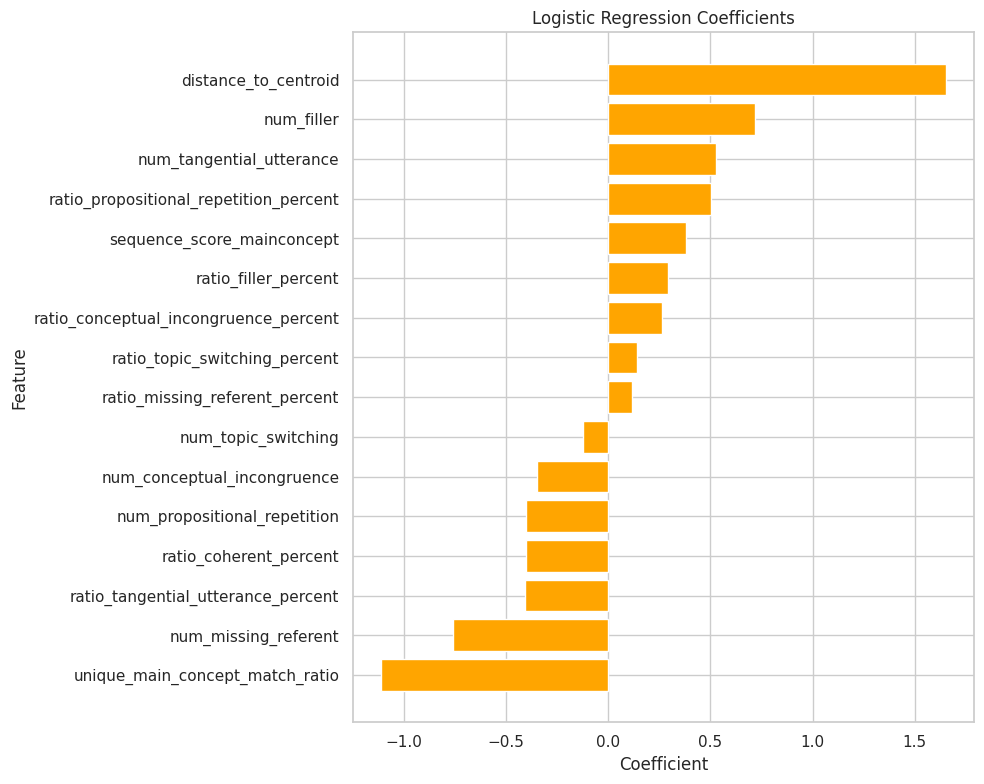

In [34]:
import matplotlib.pyplot as plt

# Sort by coefficient value (descending)
coef_df_sorted = coef_df.sort_values("coefficient", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(coef_df_sorted["feature"], coef_df_sorted["coefficient"], color="orange")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Coefficients")

# Put the highest coefficient at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [35]:
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_sorted = coef_df.sort_values('abs_coef', ascending=False)
coef_sorted

,feature,coefficient,abs_coef
0,distance_to_centroid,1.651056,1.651056
1,unique_main_concept_match_ratio,-1.111367,1.111367
5,num_missing_referent,-0.757384,0.757384
11,num_filler,0.717768,0.717768
7,num_tangential_utterance,0.529186,0.529186
10,ratio_propositional_repetition_percent,0.503058,0.503058
8,ratio_tangential_utterance_percent,-0.405145,0.405145
15,ratio_coherent_percent,-0.403644,0.403644
9,num_propositional_repetition,-0.401302,0.401302
2,sequence_score_mainconcept,0.381645,0.381645


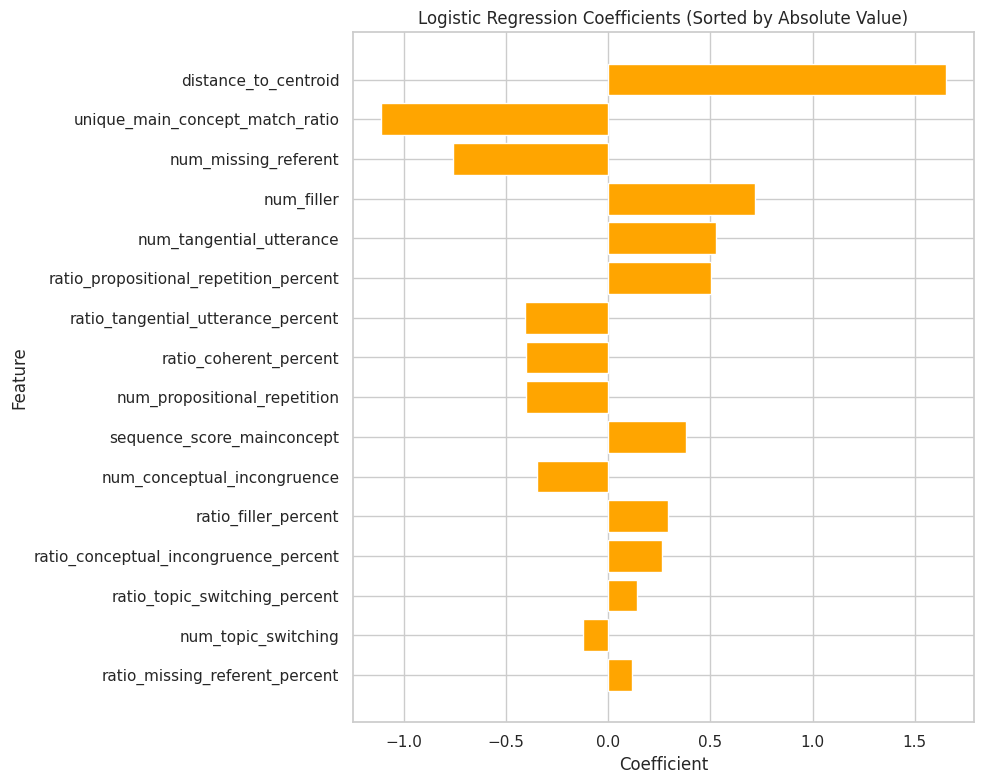

In [36]:
coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df_sorted = coef_df.sort_values("abs_coef", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(coef_df_sorted["feature"], coef_df_sorted["coefficient"], color="orange")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Coefficients (Sorted by Absolute Value)")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Cross Validation 5 Folds

In [37]:
y = df_ml['label']

X = df_ml.drop(
    columns=[
        'label',
        'participant',      # or 'combined_id' depending on what you kept
    ],
    errors='ignore'
)

## Diagnosis of False postives and False Negatives 


===== CONFUSION MATRICES (5 folds) =====

Fold 1:
[[19  3]
 [ 3 18]]

Fold 2:
[[19  3]
 [ 3 18]]

Fold 3:
[[21  2]
 [ 3 17]]

Fold 4:
[[20  3]
 [ 5 15]]

Fold 5:
[[19  4]
 [ 2 18]]

===== FINAL METRICS =====
Accuracy per fold: [0.86  0.86  0.884 0.814 0.86 ]
Mean Accuracy: 0.856
AUC per fold: [0.903 0.922 0.976 0.913 0.957]
Mean AUC: 0.934

===== GLOBAL CONFUSION MATRIX (all folds combined) =====
[[98 15]
 [16 86]]


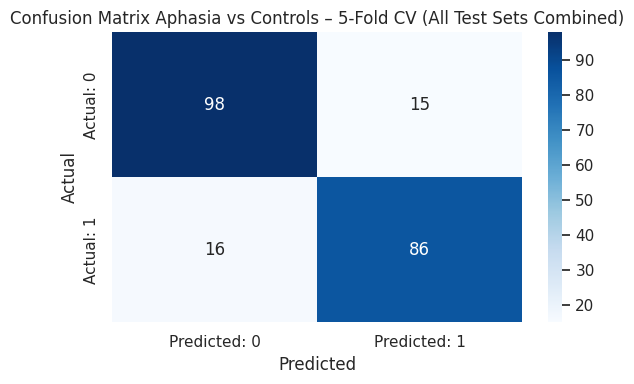

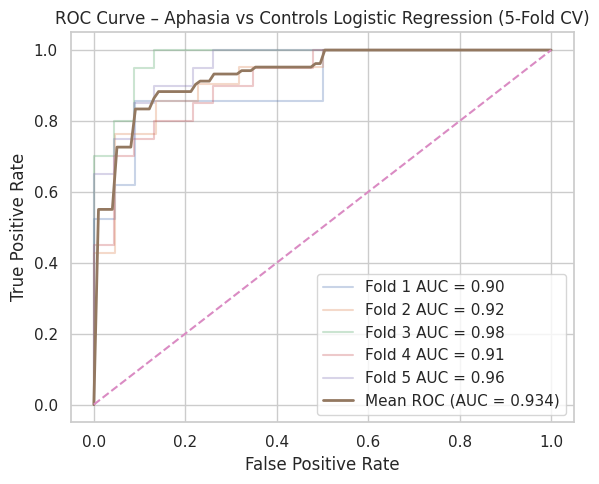

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, accuracy_score, roc_auc_score, roc_curve
)

# Logistic Regression Classifier
logreg = LogisticRegression(
    solver='liblinear',
    max_iter=500,
    class_weight='balanced'
)

# 5-Fold Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
roc_aucs = []
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)

# 👉 store per-fold curves if you want to plot them
fprs = []
tprs = []

# 👉 NEW: to build one global confusion matrix
y_true_all = []
y_pred_all = []
fold_results = [] 

print("\n===== CONFUSION MATRICES (5 folds) =====\n")

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    ids_test = participants[test_idx]  # participant IDs for lookup

    # Train & Predict
    logreg.fit(X_train_fold, y_train_fold)
    y_pred_fold = logreg.predict(X_test_fold)
    y_prob_fold = logreg.predict_proba(X_test_fold)[:, 1]  # probability for ROC

    # 👉 collect for global confusion matrix
    y_true_all.extend(y_test_fold)
    y_pred_all.extend(y_pred_fold)

    # False negative = true=1 patient, predicted=0
    fn_mask = (y_test_fold.values == 1) & (y_pred_fold == 0)
    false_negatives = ids_test[fn_mask]

    # False positive = true=0 control, predicted=1
    fp_mask = (y_test_fold.values == 0) & (y_pred_fold == 1)
    false_positives = ids_test[fp_mask]

    fold_results.append({
        "fold": fold,
        "false_negatives": false_negatives.tolist(),
        "false_positives": false_positives.tolist()
    })

    # Confusion matrix per fold (optional print)
    cm = confusion_matrix(y_test_fold, y_pred_fold)
    print(f"Fold {fold}:\n{cm}\n")

    # Metrics
    acc = accuracy_score(y_test_fold, y_pred_fold)
    auc = roc_auc_score(y_test_fold, y_prob_fold)
    accuracies.append(acc)
    roc_aucs.append(auc)

    # ROC curve aggregation
    fpr, tpr, _ = roc_curve(y_test_fold, y_prob_fold)
    fprs.append(fpr)
    tprs.append(tpr)

    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# ======= Average ROC curve =======
mean_tpr /= cv.n_splits
mean_tpr[-1] = 1.0
mean_auc = np.mean(roc_aucs)

# ======= Print Final Metrics =======
print("===== FINAL METRICS =====")
print(f"Accuracy per fold: {np.round(accuracies,3)}")
print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"AUC per fold: {np.round(roc_aucs,3)}")
print(f"Mean AUC: {mean_auc:.3f}")

# ======= 👉 ONE GLOBAL CONFUSION MATRIX ACROSS ALL 5 FOLDS =======
final_cm = confusion_matrix(y_true_all, y_pred_all)
print("\n===== GLOBAL CONFUSION MATRIX (all folds combined) =====")
print(final_cm)

# Confusion matrix heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted: 0", "Predicted: 1"],
    yticklabels=["Actual: 0", "Actual: 1"]
)
plt.title("Confusion Matrix Aphasia vs Controls – 5-Fold CV (All Test Sets Combined)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# ======= 👉 ROC CURVE PLOT (mean across 5 folds) =======
plt.figure(figsize=(6, 5))

# (optional) plot each fold ROC lightly
for i, (fpr, tpr) in enumerate(zip(fprs, tprs), start=1):
    plt.plot(fpr, tpr, alpha=0.3, label=f"Fold {i} AUC = {roc_aucs[i-1]:.2f}")

# plot mean ROC
plt.plot(mean_fpr, mean_tpr, label=f"Mean ROC (AUC = {mean_auc:.3f})", linewidth=2)

# diagonal line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Aphasia vs Controls Logistic Regression (5-Fold CV)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [39]:
misclassified_df = pd.DataFrame(fold_results)

for result in fold_results:
    fold = result["fold"]
    fns = result["false_negatives"]
    fps = result["false_positives"]

    print(f"\n===== Fold {fold} =====")

    # ---- False Negatives (Patient predicted as Control) ----
    print("\nFalse Negatives (Patient wrongly labeled Control):")
    if len(fns) > 0:
        display(participants_df[participants_df['combined_id'].isin(fns)])
    else:
        print("None")

    # ---- False Positives (Control predicted as Patient) ----
    print("\nFalse Positives (Control wrongly labeled Patient):")
    if len(fps) > 0:
        display(participants_df[participants_df['combined_id'].isin(fps)])
    else:
        print("None")


===== Fold 1 =====

False Negatives (Patient wrongly labeled Control):


,Corpus,participant,age,sex,diagnosis,WAB score,standardized MOCA,gen_diagnosis,combined_id
225,Baycrest,baycrest10827a,79,M,Aphasia,95.8,NaN,Aphasia,baycrest10827a
243,Fridriksson,fridriksson13a,55,M,Conduction,72.6,NaN,Aphasia,fridriksson13a
250,Richardson,richardson08a,48,M,Anomic,92.6,NaN,Aphasia,richardson08a



False Positives (Control wrongly labeled Patient):


,Corpus,participant,age,sex,diagnosis,WAB score,standardized MOCA,gen_diagnosis,combined_id
0,Delaware,02-1,62,F,Control,NaN,30.0,Control,delaware02-1
50,Delaware,65-1,65,F,Control,NaN,28.0,Control,delaware65-1
107,Wright,wright06a,65,F,Control,NaN,NaN,Control,wright06a



===== Fold 2 =====

False Negatives (Patient wrongly labeled Control):


,Corpus,participant,age,sex,diagnosis,WAB score,standardized MOCA,gen_diagnosis,combined_id
226,Baycrest,baycrest11154a,73,M,Aphasia,98.3,NaN,Aphasia,baycrest11154a
241,Fridriksson,fridriksson11a,35,F,NotAphasicbyWAB,99.6,NaN,Aphasia,fridriksson11a
297,Williamson,williamson07a,64,M,Anomic,92.2,NaN,Aphasia,williamson07a



False Positives (Control wrongly labeled Patient):


,Corpus,participant,age,sex,diagnosis,WAB score,standardized MOCA,gen_diagnosis,combined_id
32,Delaware,271-1,77,F,Control,NaN,28.64,Control,delaware271-1
46,Delaware,46-1,88,M,Control,NaN,25.00,Control,delaware46-1
110,Wright,wright09a,45,M,Control,NaN,NaN,Control,wright09a



===== Fold 3 =====

False Negatives (Patient wrongly labeled Control):


,Corpus,participant,age,sex,diagnosis,WAB score,standardized MOCA,gen_diagnosis,combined_id
214,Adler,adler03a,78,F,NotAphasicbyWAB,95.8,NaN,Aphasia,adler03a
258,Richardson,richardson21a,51,F,NotAphasicbyWAB,96.5,NaN,Aphasia,richardson21a
275,UNH,UNH11b,65,F,NotAphasicbyWAB,94.3,NaN,Aphasia,unh11b



False Positives (Control wrongly labeled Patient):


,Corpus,participant,age,sex,diagnosis,WAB score,standardized MOCA,gen_diagnosis,combined_id
13,Delaware,208-1,83,F,Control,NaN,27.27,Control,delaware208-1
56,Delaware,86-1,62,F,Control,NaN,27.00,Control,delaware86-1



===== Fold 4 =====

False Negatives (Patient wrongly labeled Control):


,Corpus,participant,age,sex,diagnosis,WAB score,standardized MOCA,gen_diagnosis,combined_id
221,Baycrest,baycrest12331a,68,F,Aphasia,90.8,NaN,Aphasia,baycrest12331a
223,Baycrest,baycrest9772a,70,M,Aphasia,96.7,NaN,Aphasia,baycrest9772a
257,Richardson,richardson20a,33,F,NotAphasicbyWAB,95.5,NaN,Aphasia,richardson20a
276,UNH,UNH14a,59,F,Conduction,85.3,NaN,Aphasia,unh14a
305,Wozniak,wozniak01a,54,F,Anomic,93.4,NaN,Aphasia,wozniak01a



False Positives (Control wrongly labeled Patient):


,Corpus,participant,age,sex,diagnosis,WAB score,standardized MOCA,gen_diagnosis,combined_id
3,Delaware,05-1,79,M,Control,NaN,25.00,Control,delaware05-1
31,Delaware,270-1,77,M,Control,NaN,27.27,Control,delaware270-1
63,Delaware,97-1,84,F,Control,NaN,27.00,Control,delaware97-1



===== Fold 5 =====

False Negatives (Patient wrongly labeled Control):


,Corpus,participant,age,sex,diagnosis,WAB score,standardized MOCA,gen_diagnosis,combined_id
299,Williamson,williamson10a,71,M,NotAphasicbyWAB,95.2,NaN,Aphasia,williamson10a
301,Williamson,williamson13a,69,M,NotAphasicbyWAB,99.0,NaN,Aphasia,williamson13a



False Positives (Control wrongly labeled Patient):


,Corpus,participant,age,sex,diagnosis,WAB score,standardized MOCA,gen_diagnosis,combined_id
22,Delaware,227-1,69,F,Control,NaN,30.0,Control,delaware227-1
97,Capilouto,capilouto09a,82,M,Control,NaN,NaN,Control,capilouto09a
105,Wright,wright04a,74,F,Control,NaN,NaN,Control,wright04a
109,Wright,wright08a,51,F,Control,NaN,NaN,Control,wright08a



===== CONFUSION MATRICES (5 folds) =====

Fold 1:
[[19  3]
 [ 3 18]]

Fold 2:
[[19  3]
 [ 3 18]]

Fold 3:
[[21  2]
 [ 3 17]]

Fold 4:
[[20  3]
 [ 5 15]]

Fold 5:
[[19  4]
 [ 2 18]]

===== FINAL METRICS =====
Accuracy per fold: [0.86  0.86  0.884 0.814 0.86 ]
Mean Accuracy: 0.856
AUC per fold: [0.903 0.922 0.976 0.913 0.957]
Mean AUC: 0.934

===== GLOBAL CONFUSION MATRIX (all folds combined) =====
[[98 15]
 [16 86]]


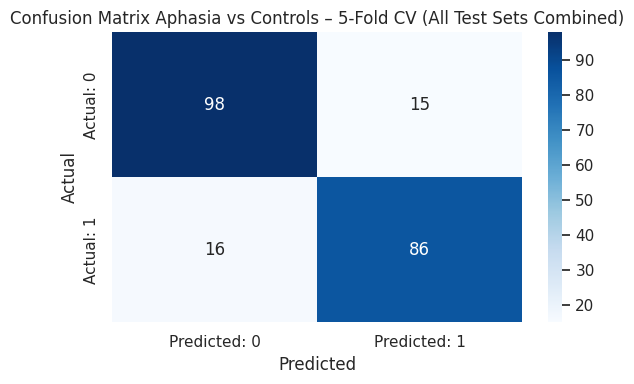

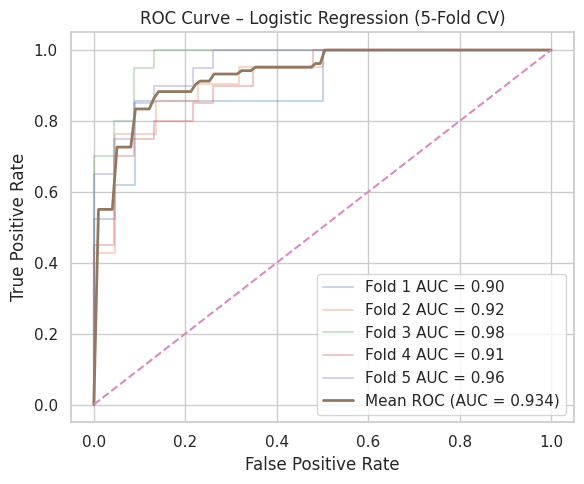

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, accuracy_score, roc_auc_score, roc_curve
)

# Logistic Regression Classifier
logreg = LogisticRegression(
    solver='liblinear',
    max_iter=500,
    class_weight='balanced'
)

# 5-Fold Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
roc_aucs = []
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)

# 👉 store per-fold curves if you want to plot them
fprs = []
tprs = []

# 👉 NEW: to build one global confusion matrix
y_true_all = []
y_pred_all = []
fold_results = [] 

print("\n===== CONFUSION MATRICES (5 folds) =====\n")

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    ids_test = participants[test_idx]  # participant IDs for lookup

    # Train & Predict
    logreg.fit(X_train_fold, y_train_fold)
    y_pred_fold = logreg.predict(X_test_fold)
    y_prob_fold = logreg.predict_proba(X_test_fold)[:, 1]  # probability for ROC

    # 👉 collect for global confusion matrix
    y_true_all.extend(y_test_fold)
    y_pred_all.extend(y_pred_fold)

    # False negative = true=1 patient, predicted=0
    fn_mask = (y_test_fold.values == 1) & (y_pred_fold == 0)
    false_negatives = ids_test[fn_mask]

    # False positive = true=0 control, predicted=1
    fp_mask = (y_test_fold.values == 0) & (y_pred_fold == 1)
    false_positives = ids_test[fp_mask]

    fold_results.append({
        "fold": fold,
        "false_negatives": false_negatives.tolist(),
        "false_positives": false_positives.tolist()
    })

    # Confusion matrix per fold (optional print)
    cm = confusion_matrix(y_test_fold, y_pred_fold)
    print(f"Fold {fold}:\n{cm}\n")

    # Metrics
    acc = accuracy_score(y_test_fold, y_pred_fold)
    auc = roc_auc_score(y_test_fold, y_prob_fold)
    accuracies.append(acc)
    roc_aucs.append(auc)

    # ROC curve aggregation
    fpr, tpr, _ = roc_curve(y_test_fold, y_prob_fold)
    fprs.append(fpr)
    tprs.append(tpr)

    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# ======= Average ROC curve =======
mean_tpr /= cv.n_splits
mean_tpr[-1] = 1.0
mean_auc = np.mean(roc_aucs)

# ======= Print Final Metrics =======
print("===== FINAL METRICS =====")
print(f"Accuracy per fold: {np.round(accuracies,3)}")
print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"AUC per fold: {np.round(roc_aucs,3)}")
print(f"Mean AUC: {mean_auc:.3f}")

# ======= 👉 ONE GLOBAL CONFUSION MATRIX ACROSS ALL 5 FOLDS =======
final_cm = confusion_matrix(y_true_all, y_pred_all)
print("\n===== GLOBAL CONFUSION MATRIX (all folds combined) =====")
print(final_cm)

# Confusion matrix heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted: 0", "Predicted: 1"],
    yticklabels=["Actual: 0", "Actual: 1"]
)
plt.title("Confusion Matrix Aphasia vs Controls – 5-Fold CV (All Test Sets Combined)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# ======= 👉 ROC CURVE PLOT (mean across 5 folds) =======
plt.figure(figsize=(6, 5))

# (optional) plot each fold ROC lightly
for i, (fpr, tpr) in enumerate(zip(fprs, tprs), start=1):
    plt.plot(fpr, tpr, alpha=0.3, label=f"Fold {i} AUC = {roc_aucs[i-1]:.2f}")

# plot mean ROC
plt.plot(mean_fpr, mean_tpr, label=f"Mean ROC (AUC = {mean_auc:.3f})", linewidth=2)

# diagonal line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression (5-Fold CV)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, accuracy_score, roc_auc_score, roc_curve
)

# Logistic Regression Classifier
logreg = LogisticRegression(
    solver='liblinear',
    max_iter=500,
    class_weight='balanced'
)

# 5-Fold Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
roc_aucs = []
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)

print("\n===== CONFUSION MATRICES (5 folds) =====\n")

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

    # Train & Predict
    logreg.fit(X_train_fold, y_train_fold)
    y_pred_fold = logreg.predict(X_test_fold)
    y_prob_fold = logreg.predict_proba(X_test_fold)[:, 1]  # probability for ROC

    # Confusion matrix
    cm = confusion_matrix(y_test_fold, y_pred_fold)
    print(f"Fold {fold}:\n{cm}\n")

    # Metrics
    acc = accuracy_score(y_test_fold, y_pred_fold)
    auc = roc_auc_score(y_test_fold, y_prob_fold)
    accuracies.append(acc)
    roc_aucs.append(auc)

    # ROC curve aggregation
    fpr, tpr, _ = roc_curve(y_test_fold, y_prob_fold)
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Average ROC curve
mean_tpr /= cv.n_splits
mean_tpr[-1] = 1.0
mean_auc = np.mean(roc_aucs)

# ======= Print Final Metrics =======
print("===== FINAL METRICS =====")
print(f"Accuracy per fold: {np.round(accuracies,3)}")
print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"AUC per fold: {np.round(roc_aucs,3)}")
print(f"Mean AUC: {mean_auc:.3f}")



===== CONFUSION MATRICES (5 folds) =====

Fold 1:
[[19  3]
 [ 3 18]]

Fold 2:
[[19  3]
 [ 3 18]]

Fold 3:
[[21  2]
 [ 3 17]]

Fold 4:
[[20  3]
 [ 5 15]]

Fold 5:
[[19  4]
 [ 2 18]]

===== FINAL METRICS =====
Accuracy per fold: [0.86  0.86  0.884 0.814 0.86 ]
Mean Accuracy: 0.856
AUC per fold: [0.903 0.922 0.976 0.913 0.957]
Mean AUC: 0.934


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
import pandas as pd
import numpy as np

logreg = LogisticRegression(
    solver='liblinear',
    max_iter=500,
    class_weight='balanced'
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

coef_list = []

for train_idx, test_idx in cv.split(X, y):
    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    
    logreg.fit(X_train_fold, y_train_fold)
    
    # store coef (flatten to 1D)
    coef_list.append(logreg.coef_.flatten())

# Convert to DataFrame: rows = folds, columns = features
remove_cols = ['participant', 'gen_diagnosis']
feature_cols = [c for c in feature_cols if c not in remove_cols]
coef_df_all = pd.DataFrame(coef_list, columns=feature_cols)
coef_df_all



,distance_to_centroid,unique_main_concept_match_ratio,sequence_score_mainconcept,num_topic_switching,ratio_topic_switching_percent,num_missing_referent,ratio_missing_referent_percent,num_tangential_utterance,ratio_tangential_utterance_percent,num_propositional_repetition,ratio_propositional_repetition_percent,num_filler,ratio_filler_percent,num_conceptual_incongruence,ratio_conceptual_incongruence_percent,ratio_coherent_percent
0,1.623997,-0.963483,0.346600,-0.225400,0.391411,-0.924586,0.155876,0.359870,-0.000473,-0.202671,0.245154,0.641614,-0.034710,-0.307012,0.345397,-0.528126
1,1.851878,-1.216940,0.252603,-0.116525,0.065526,-0.839889,0.031449,0.570847,-0.275340,-0.598108,0.653563,0.828243,0.252029,-0.565691,0.083444,-0.216856
2,1.763863,-1.235136,0.157670,-0.163842,0.037810,-0.675418,-0.056576,0.447119,-0.261427,-0.388707,0.316378,0.649610,-0.011108,-0.289188,0.484858,-0.264826
3,2.206218,-1.642154,0.196600,-0.459059,-0.041691,-0.568669,0.013676,0.695878,-0.234691,-0.314624,0.444938,0.409856,0.433231,-0.213565,0.411186,-0.449045
4,1.867388,-1.274713,0.299621,-0.102145,-0.017922,-0.562080,-0.096938,-0.010710,-0.098064,-0.412832,0.416296,0.778296,0.354249,-0.038690,0.149080,-0.186286


In [43]:
K = 16  # choose top K features to vote

votes = pd.Series(0, index=feature_cols)

for i in range(len(coef_df_all)):
    fold_coefs = coef_df_all.iloc[i].abs()
    top_k = fold_coefs.nlargest(K).index
    votes[top_k] += 1

votes_sorted = votes.sort_values(ascending=False)
print("\n=== Most Voted Features Across Folds ===")
print(votes_sorted)



=== Most Voted Features Across Folds ===
distance_to_centroid                      5
unique_main_concept_match_ratio           5
sequence_score_mainconcept                5
num_topic_switching                       5
ratio_topic_switching_percent             5
num_missing_referent                      5
ratio_missing_referent_percent            5
num_tangential_utterance                  5
ratio_tangential_utterance_percent        5
num_propositional_repetition              5
ratio_propositional_repetition_percent    5
num_filler                                5
ratio_filler_percent                      5
num_conceptual_incongruence               5
ratio_conceptual_incongruence_percent     5
ratio_coherent_percent                    5
dtype: int64


In [44]:
# Mean signed coefficients (keep sign)
mean_signed_coef = coef_df_all.mean()

# Mean absolute coefficient (for ordering)
mean_abs_coef = coef_df_all.abs().mean()

# Combine into one DataFrame
importance_signed = pd.DataFrame({
    "mean_coef": mean_signed_coef,
    "mean_abs_coef": mean_abs_coef,
    "votes": votes_sorted  # if you computed votes earlier
})

# Sort by abs value
importance_signed = importance_signed.sort_values("mean_abs_coef", ascending=False)
importance_signed.head()


,mean_coef,mean_abs_coef,votes
distance_to_centroid,1.862669,1.862669,5
unique_main_concept_match_ratio,-1.266485,1.266485,5
num_missing_referent,-0.714128,0.714128,5
num_filler,0.661524,0.661524,5
num_tangential_utterance,0.412601,0.416885,5


In [45]:
print(importance_signed)

                                        mean_coef  mean_abs_coef  votes
distance_to_centroid                     1.862669       1.862669      5
unique_main_concept_match_ratio         -1.266485       1.266485      5
num_missing_referent                    -0.714128       0.714128      5
num_filler                               0.661524       0.661524      5
num_tangential_utterance                 0.412601       0.416885      5
ratio_propositional_repetition_percent   0.415266       0.415266      5
num_propositional_repetition            -0.383388       0.383388      5
ratio_coherent_percent                  -0.329028       0.329028      5
ratio_conceptual_incongruence_percent    0.294793       0.294793      5
num_conceptual_incongruence             -0.282830       0.282830      5
sequence_score_mainconcept               0.250619       0.250619      5
ratio_filler_percent                     0.198738       0.217065      5
num_topic_switching                     -0.213394       0.213394

In [46]:
# Mean coefficient across folds
mean_coef = coef_df_all.mean()

# Sort by absolute magnitude
sorted_abs = mean_coef.abs().sort_values(ascending=False)

sorted_abs

distance_to_centroid                      1.862669
unique_main_concept_match_ratio           1.266485
num_missing_referent                      0.714128
num_filler                                0.661524
ratio_propositional_repetition_percent    0.415266
num_tangential_utterance                  0.412601
num_propositional_repetition              0.383388
ratio_coherent_percent                    0.329028
ratio_conceptual_incongruence_percent     0.294793
num_conceptual_incongruence               0.282830
sequence_score_mainconcept                0.250619
num_topic_switching                       0.213394
ratio_filler_percent                      0.198738
ratio_tangential_utterance_percent        0.173999
ratio_topic_switching_percent             0.087027
ratio_missing_referent_percent            0.009497
dtype: float64

In [47]:
importance_signed = importance_signed.reindex(
    importance_signed["mean_coef"].abs().sort_values(ascending=False).index
)


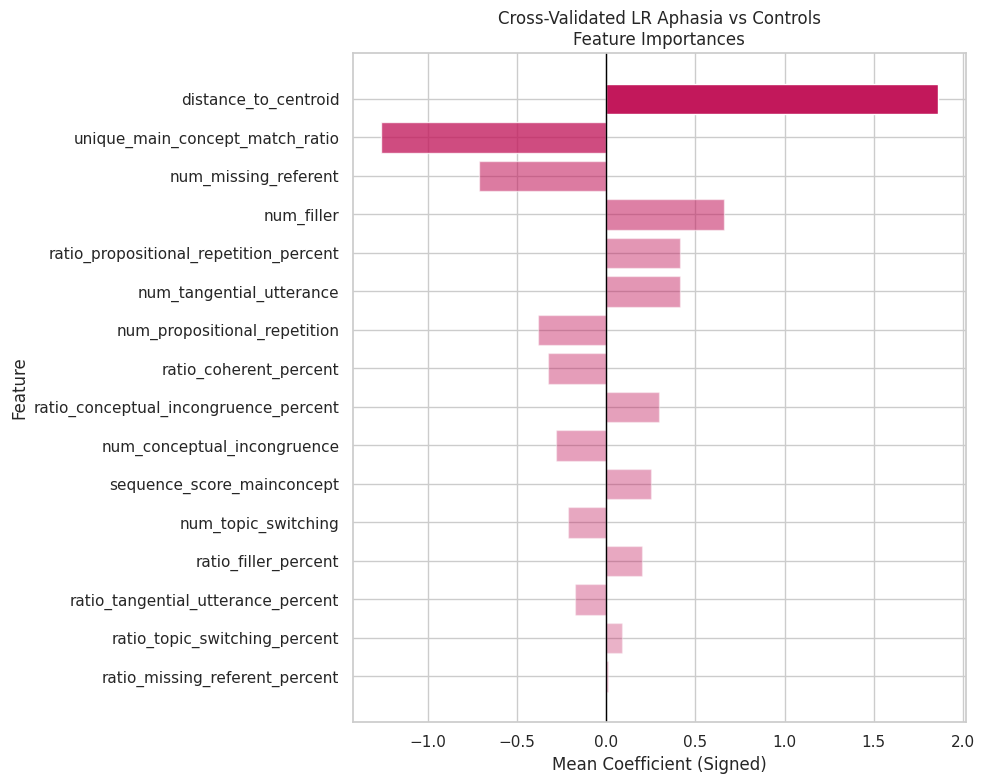

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Normalize importance for alpha
abs_vals = importance_signed["mean_coef"].abs()
alpha_vals = 0.3 + 0.7 * (abs_vals / abs_vals.max())  # range [0.3, 1.0]

plt.figure(figsize=(10, 8))

for i, (feat, coef, alpha) in enumerate(
    zip(importance_signed.index,
        importance_signed["mean_coef"],
        alpha_vals)
):
    plt.barh(
        feat,
        coef,
        color="#C2185B",   # reddish-pink
        alpha=alpha
    )

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Mean Coefficient (Signed)")
plt.ylabel("Feature")
plt.title("Cross-Validated LR Aphasia vs Controls\nFeature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



## Stability Check LOOCV

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("clf", LogisticRegression(
        solver="liblinear",
        max_iter=500,
        class_weight="balanced"
    ))
])

loo = LeaveOneOut()

coef_list = []
for train_idx, test_idx in loo.split(X, y):
    pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
    coef_list.append(pipe.named_steps["clf"].coef_.ravel())

coef_loo = pd.DataFrame(coef_list, columns=X.columns)

# stability summary
votes_pos = (coef_loo > 0).sum()
votes_neg = (coef_loo < 0).sum()
n_folds = len(coef_loo)

summary = pd.DataFrame({
    "mean_coef": coef_loo.mean(),
    "std_coef": coef_loo.std(),
    "mean_abs_coef": coef_loo.abs().mean(),
    "votes_pos": votes_pos,
    "votes_neg": votes_neg,
    "n_folds": n_folds,
    "sign_consistency": (votes_pos - votes_neg).abs() / n_folds
}).sort_values("mean_abs_coef", ascending=False)
summary
# ---- PLOT ----
# TOP_N = 20
# top = summary.head(TOP_N).iloc[::-1]  # reverse for barh

# plt.figure(figsize=(10, 8))
# plt.barh(
#     top.index,
#     top["mean_coef"],
#     color=["green" if v > 0 else "red" for v in top["mean_coef"]]
# )
# plt.axvline(0, linestyle="--", linewidth=1)
# plt.xlabel("Mean LOOCV Coefficient (signed)")
# plt.title(f"LOOCV LR Coefficients (Aphasia vs Control) — Top {TOP_N} by mean |coef|")
# plt.tight_layout()
# plt.show()


,mean_coef,std_coef,mean_abs_coef,votes_pos,votes_neg,n_folds,sign_consistency
distance_to_centroid,1.993471,0.033219,1.993471,215,0,215,1.000000
unique_main_concept_match_ratio,-1.343793,0.030874,1.343793,0,215,215,1.000000
num_missing_referent,-0.705900,0.030528,0.705900,0,215,215,1.000000
num_filler,0.678923,0.025588,0.678923,215,0,215,1.000000
ratio_propositional_repetition_percent,0.479822,0.025232,0.479822,215,0,215,1.000000
num_tangential_utterance,0.474470,0.028114,0.474470,215,0,215,1.000000
num_propositional_repetition,-0.415064,0.021400,0.415064,0,215,215,1.000000
num_conceptual_incongruence,-0.369635,0.026028,0.369635,0,215,215,1.000000
ratio_conceptual_incongruence_percent,0.283074,0.024289,0.283074,215,0,215,1.000000
ratio_coherent_percent,-0.270949,0.015954,0.270949,0,215,215,1.000000


In [51]:
import numpy as np
import pandas as pd

K = 10  # pick top-K features per fold (common: 5, 10, 20)

abs_coef = coef_loo.abs()

# boolean matrix: True if feature is in top-K abs coef in that fold
selected = abs_coef.apply(lambda row: row.nlargest(K).index, axis=1)

selected_mask = pd.DataFrame(False, index=coef_loo.index, columns=coef_loo.columns)
for i, feats in selected.items():
    selected_mask.loc[i, feats] = True

# selection frequency (%)
selection_freq = selected_mask.mean(axis=0) * 100  # percent
selection_freq = selection_freq.sort_values(ascending=False)

selection_freq.head(20)

distance_to_centroid                      100.000000
unique_main_concept_match_ratio           100.000000
num_tangential_utterance                  100.000000
num_missing_referent                      100.000000
ratio_propositional_repetition_percent    100.000000
num_filler                                100.000000
num_propositional_repetition              100.000000
num_conceptual_incongruence                98.604651
ratio_conceptual_incongruence_percent      94.883721
ratio_coherent_percent                     93.488372
ratio_tangential_utterance_percent          7.441860
sequence_score_mainconcept                  4.186047
ratio_filler_percent                        0.930233
num_topic_switching                         0.465116
ratio_missing_referent_percent              0.000000
ratio_topic_switching_percent               0.000000
dtype: float64

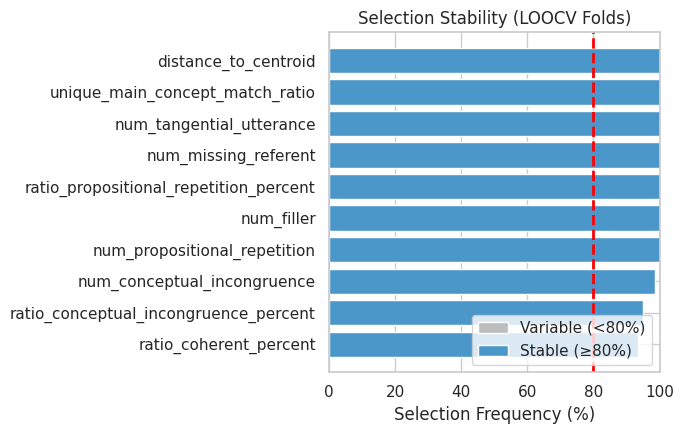

In [52]:
import matplotlib.pyplot as plt

THRESH = 80
TOP_N = 10

plot_series = selection_freq.head(TOP_N)[::-1]  # reverse for barh
colors = ["#4C97C9" if v >= THRESH else "#BDBDBD" for v in plot_series.values]

plt.figure(figsize=(7, 4.5))
plt.barh(plot_series.index, plot_series.values, color=colors)
plt.axvline(THRESH, color="red", linestyle="--", linewidth=2)

plt.xlabel("Selection Frequency (%)")
plt.title("Selection Stability (LOOCV Folds)")
plt.xlim(0, 100)

# legend
from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(facecolor="#BDBDBD", label=f"Variable (<{THRESH}%)"),
    Patch(facecolor="#4C97C9", label=f"Stable (≥{THRESH}%)")
], loc="lower right")

plt.tight_layout()
plt.show()


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeavePOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ---- X, y (participant-level) ----
# assumes df_ml already created as you showed
y = df_ml["label"].copy()
X = df_ml.drop(columns=["participant", "label"], errors="ignore").copy()

# ---- model (same as yours) ----
pipe = Pipeline([
    ("clf", LogisticRegression(
        solver="liblinear",
        max_iter=500,
        class_weight="balanced"
    ))
])

# ---- Leave-Two-Out CV ----
lpo = LeavePOut(p=2)

coef_list = []
for train_idx, test_idx in lpo.split(X, y):
    pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
    coef_list.append(pipe.named_steps["clf"].coef_.ravel())

coef_lto = pd.DataFrame(coef_list, columns=X.columns)
n_folds = len(coef_lto)
print("LTOCV folds:", n_folds)  # should be 23005 for N=215

# ---- coefficient summary ----
votes_pos = (coef_lto > 0).sum()
votes_neg = (coef_lto < 0).sum()

summary_lto = pd.DataFrame({
    "mean_coef": coef_lto.mean(),
    "std_coef": coef_lto.std(),
    "mean_abs_coef": coef_lto.abs().mean(),
    "votes_pos": votes_pos,
    "votes_neg": votes_neg,
    "n_folds": n_folds,
    "sign_consistency": (votes_pos - votes_neg).abs() / n_folds
}).sort_values("mean_abs_coef", ascending=False)

summary_lto.head(20)


LTOCV folds: 23005


,mean_coef,std_coef,mean_abs_coef,votes_pos,votes_neg,n_folds,sign_consistency
distance_to_centroid,1.990919,0.046897,1.990919,23005,0,23005,1.000000
unique_main_concept_match_ratio,-1.342752,0.043631,1.342752,0,23005,23005,1.000000
num_missing_referent,-0.706017,0.043059,0.706017,0,23005,23005,1.000000
num_filler,0.678772,0.036059,0.678772,23005,0,23005,1.000000
ratio_propositional_repetition_percent,0.478644,0.035623,0.478644,23005,0,23005,1.000000
num_tangential_utterance,0.473010,0.039707,0.473010,23005,0,23005,1.000000
num_propositional_repetition,-0.413979,0.030171,0.413979,0,23005,23005,1.000000
num_conceptual_incongruence,-0.367977,0.036701,0.367977,0,23005,23005,1.000000
ratio_conceptual_incongruence_percent,0.283142,0.034253,0.283142,23004,1,23005,0.999913
ratio_coherent_percent,-0.271938,0.022556,0.271938,0,23005,23005,1.000000


In [54]:
K = 10  # choose 5/10/20 depending on how many you want to “select”

abs_coef = coef_lto.abs()

# build boolean selection mask: selected if in top-K abs coef that fold
selected_mask = pd.DataFrame(False, index=abs_coef.index, columns=abs_coef.columns)

topk_idx_per_fold = abs_coef.apply(lambda row: row.nlargest(K).index, axis=1)
for i, feats in topk_idx_per_fold.items():
    selected_mask.loc[i, feats] = True

selection_freq = (selected_mask.mean(axis=0) * 100).sort_values(ascending=False)
selection_freq.head(20)


distance_to_centroid                      100.000000
unique_main_concept_match_ratio           100.000000
num_missing_referent                      100.000000
num_filler                                100.000000
ratio_propositional_repetition_percent     99.969572
num_propositional_repetition               99.947837
num_tangential_utterance                   99.926103
num_conceptual_incongruence                97.626603
ratio_conceptual_incongruence_percent      90.784612
ratio_coherent_percent                     87.976527
ratio_tangential_utterance_percent         13.053684
sequence_score_mainconcept                  7.294067
ratio_filler_percent                        1.999565
num_topic_switching                         1.277983
ratio_missing_referent_percent              0.134753
ratio_topic_switching_percent               0.008694
dtype: float64

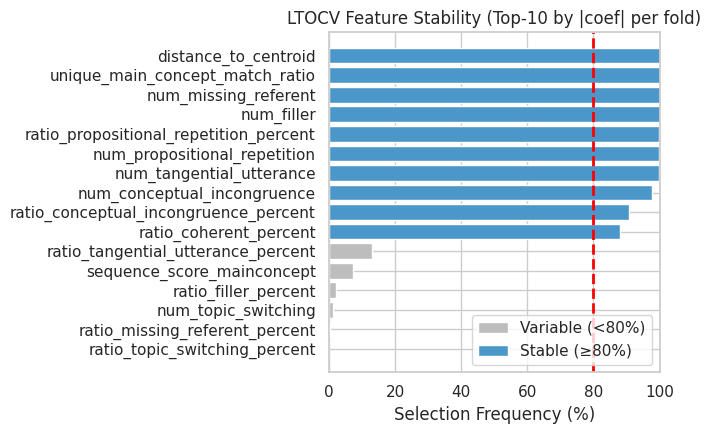

In [56]:
THRESH = 80
TOP_N = 16

plot_series = selection_freq.head(TOP_N)[::-1]
colors = ["#4C97C9" if v >= THRESH else "#BDBDBD" for v in plot_series.values]

plt.figure(figsize=(7, 4.5))
plt.barh(plot_series.index, plot_series.values, color=colors)
plt.axvline(THRESH, color="red", linestyle="--", linewidth=2)

plt.xlabel("Selection Frequency (%)")
plt.title(f"LTOCV Feature Stability (Top-{K} by |coef| per fold)")
plt.xlim(0, 100)

from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(facecolor="#BDBDBD", label=f"Variable (<{THRESH}%)"),
    Patch(facecolor="#4C97C9", label=f"Stable (≥{THRESH}%)")
], loc="lower right")

plt.tight_layout()
plt.show()
